In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,
f1_score,  precision_recall_curve, confusion_matrix, auc, roc_curve)
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.autolayout': True})

import json
import os

In [2]:
DATA_PATH = "/kaggle/input/datasets/omarhusnye/electronicsnew/clean_events_electronics_computers.csv"
df = pd.read_csv(DATA_PATH)
df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,year,...,category_l1,category_l2,category_l3,is_pc_component,component_type,product_group,is_likely_bot_session,price_band,brand_is_unknown,category_l3_is_unknown
0,2020-09-24 11:57:06+00:00,view,1996170,2144415922528452715,electronics.telephone,unknown,31.90,1515915625519388267,LJuJVLEjPT,2020,...,electronics,telephone,unknown,False,not_a_component,Mobile & Telephony,False,$25-50,1,1
1,2020-09-24 11:57:26+00:00,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY,2020,...,computers,components,cooler,True,cooler,PC Components,False,<$25,0,0
2,2020-09-24 11:57:33+00:00,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08,2020,...,computers,peripherals,printer,False,not_a_component,PC Peripherals,False,$100-250,0,0
3,2020-09-24 11:58:23+00:00,view,3791349,2144415935086199225,computers.desktop,unknown,215.41,1515915625519388877,J1t6sIYXiV,2020,...,computers,desktop,unknown,False,not_a_component,PC Systems,False,$100-250,1,1
4,2020-09-24 11:58:24+00:00,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388882,kVBeYDPcBw,2020,...,computers,network,router,False,not_a_component,PC Peripherals,False,$50-100,0,0
5,2020-09-24 11:58:31+00:00,view,716611,2144415923694469257,computers.network.router,d-link,53.14,1515915625519388929,F3VB9LYp39,2020,...,computers,network,router,False,not_a_component,PC Peripherals,False,$50-100,0,0
6,2020-09-24 12:00:00+00:00,view,1080093,2144415923107266682,computers.peripherals.printer,ricoh,268.17,1515915625519389483,63xjTFC54g,2020,...,computers,peripherals,printer,False,not_a_component,PC Peripherals,False,$250-500,0,0
7,2020-09-24 12:00:01+00:00,view,1455459,2144415927049912542,electronics.video.tv,sony,635.63,1515915625519385419,sF2S2yMO09,2020,...,electronics,video,tv,False,not_a_component,Video & Cameras,False,$500-1k,0,0
8,2020-09-24 12:00:33+00:00,view,523117,2144415924491387038,computers.components.motherboard,asrock,73.81,1515915625519334445,HycmCUvnFr,2020,...,computers,components,motherboard,True,motherboard,PC Components,False,$50-100,0,0
9,2020-09-24 12:00:37+00:00,view,10914,2144415925053423789,electronics.camera.video,sony,40.95,1515915625519389726,kYKAorW97d,2020,...,electronics,camera,video,False,not_a_component,Video & Cameras,False,$25-50,0,0


In [3]:
# Sort events chronologically
df['event_time'] = pd.to_datetime(df['event_time'])
df = df.sort_values(['user_session', 'event_time']).reset_index(drop=True)


print("Filtering sessions with Cart events...")
cart_sessions = df[df['event_type'] == 'cart']['user_session'].unique()
df_cart = df[df['user_session'].isin(cart_sessions)].copy()

Filtering sessions with Cart events...


In [4]:
# Define Target Function per session: Did they purchase after adding to cart?
session_labels = []
grouped = df_cart.groupby('user_session')

for session_id, group in grouped:
    has_cart = ('cart' in group['event_type'].values)
    has_purchase = ('purchase' in group['event_type'].values)
    
    if has_cart:
        # Target = 1 if Cart abandonment (Added to cart, but NO purchase)
        # Target = 0 if Converted (Added to cart AND purchased)
        abandoned = 1 if not has_purchase else 0
        session_labels.append({'user_session': session_id, 'abandoned': abandoned})

labels_df = pd.DataFrame(session_labels)
print(f"Total Cart Sessions Identified: {len(labels_df)}")
print(labels_df['abandoned'].value_counts())

Total Cart Sessions Identified: 27162
abandoned
1    13815
0    13347
Name: count, dtype: int64


In [5]:
print("Engineering cart behavior features...")

feature_rows = []
for session_id, group in grouped:
    # Consider actions up to the last event in the session
    view_count = (group['event_type'] == 'view').sum()
    cart_count = (group['event_type'] == 'cart').sum()

    unique_products = group['product_id'].nunique()
    unique_brands = group['brand'].nunique()
    
    average_price = group['price'].mean()
    max_price = group['price'].max()
    min_price = group['price'].min()
    
    duration = (group['event_time'].max() - group['event_time'].min()).total_seconds()
    
    # Last event details before abandonment check
    last_event = group.iloc[-1]
    
    feature_rows.append({
        'user_session': session_id,
        'view_count': view_count,
        'cart_count': cart_count,
        'unique_products': unique_products,
        'unique_brands': unique_brands,
        'average_price': average_price,
        'max_price': max_price,
        'min_price': min_price,
        'session_duration': duration,
        'last_event_type': str(last_event['event_type']),
        'last_product_id': str(last_event.get('product_id', 'missing')),
        'last_category_id': str(last_event.get('category_id', 'missing')),
        'last_brand': str(last_event.get('brand', 'missing')),
        'last_category_code': str(last_event.get('category_code', 'missing'))
    })

features_df = pd.DataFrame(feature_rows)

# Merge features with our Cart Abandonment Target Labels
model_data = pd.merge(features_df, labels_df, on='user_session')
model_data = model_data.drop(columns=['user_session'])

print(f"Final Model Dataset Shape: {model_data.shape}")

Engineering cart behavior features...
Final Model Dataset Shape: (27162, 14)


In [6]:
X = model_data.drop(columns=['abandoned'])
y = model_data['abandoned']

# Handle missing strings natively
cat_cols = ['last_event_type', 'last_product_id', 'last_category_id', 'last_brand', 'last_category_code']
for col in cat_cols:
    X[col] = X[col].fillna('missing').astype(str)

# Split data (70% Train, 15% Val, 15% Test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set rows: {len(X_train)}")

Training set rows: 19013


In [7]:
# Initialize and Train CatBoost
abandon_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.03,
    auto_class_weights='Balanced',
    loss_function='Logloss',
    eval_metric='PRAUC',
    random_seed=42,
    verbose=50
)

cat_indices = [X_train.columns.get_loc(c) for c in cat_cols]

abandon_model.fit(
    X_train, y_train,
    cat_features=cat_indices,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

0:	learn: 0.9460752	test: 0.9433846	best: 0.9433846 (0)	total: 82.6ms	remaining: 24.7s
50:	learn: 0.9591855	test: 0.9546048	best: 0.9546048 (50)	total: 1.16s	remaining: 5.65s
100:	learn: 0.9614516	test: 0.9557317	best: 0.9557317 (100)	total: 2.23s	remaining: 4.39s
150:	learn: 0.9630417	test: 0.9564610	best: 0.9564610 (150)	total: 3.28s	remaining: 3.24s
200:	learn: 0.9640995	test: 0.9566699	best: 0.9566704 (199)	total: 4.33s	remaining: 2.13s
250:	learn: 0.9650563	test: 0.9567948	best: 0.9568457 (226)	total: 5.33s	remaining: 1.04s
299:	learn: 0.9659533	test: 0.9569971	best: 0.9570110 (298)	total: 6.31s	remaining: 0us

bestTest = 0.9570110336
bestIteration = 298

Shrink model to first 299 iterations.


CatBoostClassifier(auto_class_weights='Balanced', depth=6, eval_metric='PRAUC', iterations=300, learning_rate=0.03, loss_function='Logloss', random_seed=42, verbose=50)

In [8]:
# Test Evaluation
y_test_proba = abandon_model.predict_proba(X_test)[:, 1]
test_prauc = average_precision_score(y_test, y_test_proba)
test_roc = roc_auc_score(y_test, y_test_proba)

print("\n" + "=" * 60)
print("CART ABANDONMENT MODEL EVALUATION (TEST SET)")
print("=" * 60)

print(f"Test ROC-AUC: {test_roc:.4f}")
print(f"Test PR-AUC: {test_prauc:.4f}")

y_test_pred = (y_test_proba >= 0.50).astype(int)
print("\n--- Classification Report ---")
print(classification_report(y_test, y_test_pred, digits=4))


CART ABANDONMENT MODEL EVALUATION (TEST SET)
Test ROC-AUC : 0.9590
Test PR-AUC  : 0.9623

--- Classification Report ---
              precision    recall  f1-score   support

           0     0.8585    0.8791    0.8687      2002
           1     0.8805    0.8601    0.8702      2073

    accuracy                         0.8694      4075
   macro avg     0.8695    0.8696    0.8694      4075
weighted avg     0.8697    0.8694    0.8695      4075



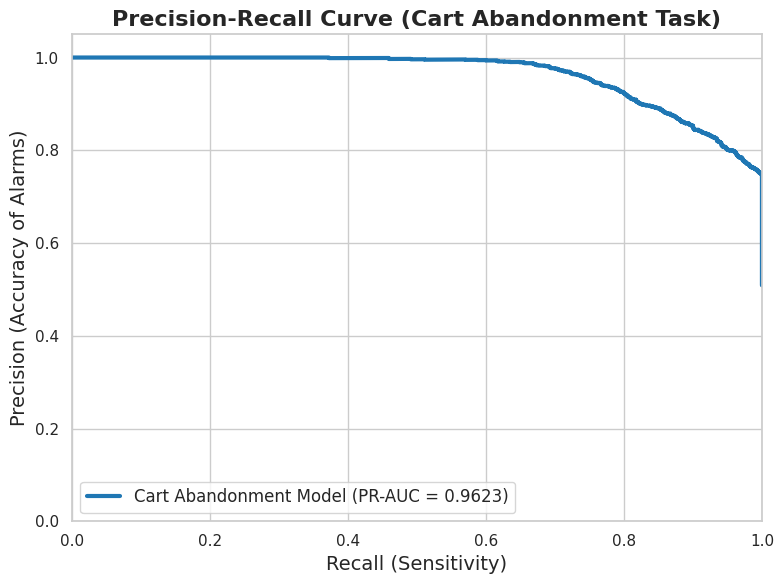

In [11]:
# Precision-Recall Curve Visualization
plt.figure(figsize=(8, 6))
precision, recall, thresholds = precision_recall_curve(y_test, y_test_proba)
pr_auc_val = auc(recall, precision)

plt.plot(recall, precision, color='#1f77b4', lw=3, label=f'Cart Abandonment Model (PR-AUC = {pr_auc_val:.4f})')
plt.xlabel('Recall (Sensitivity)', fontsize=14)
plt.ylabel('Precision (Accuracy of Alarms)', fontsize=14)
plt.title('Precision-Recall Curve (Cart Abandonment Task)', fontsize=16, fontweight='bold')
plt.legend(loc='lower left', fontsize=12)
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.savefig('/kaggle/working/pr_curve.png', dpi=300)
plt.show()

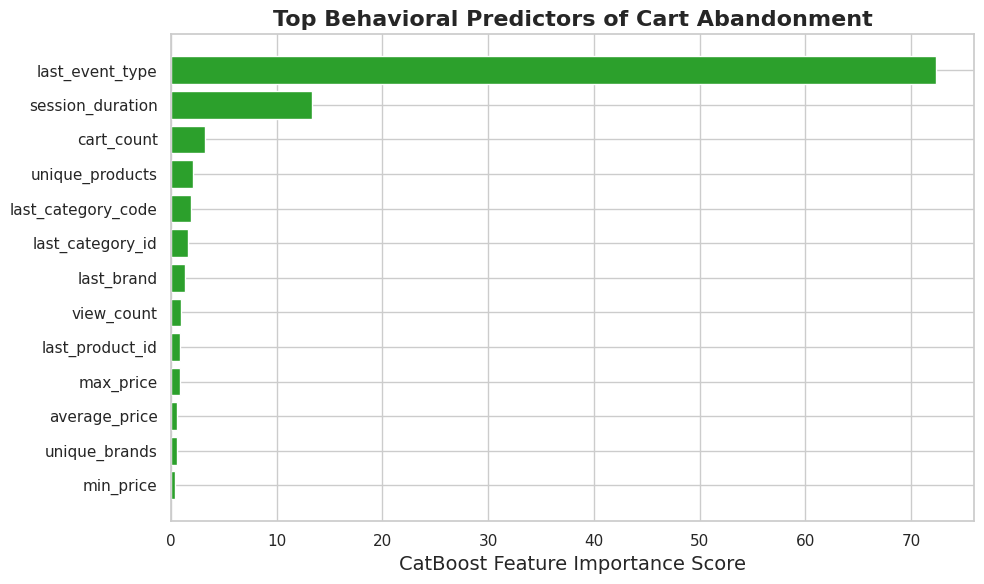

In [12]:
# Feature Importance Visualization
plt.figure(figsize=(10, 6))
feature_importances = abandon_model.get_feature_importance()
feature_names = X_train.columns

# Sort features by importance
sorted_idx = np.argsort(feature_importances)
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], color='#2ca02c')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.xlabel('CatBoost Feature Importance Score', fontsize=14)
plt.title('Top Behavioral Predictors of Cart Abandonment', fontsize=16, fontweight='bold')
plt.savefig('/kaggle/working/feature_importance.png', dpi=300)
plt.show()

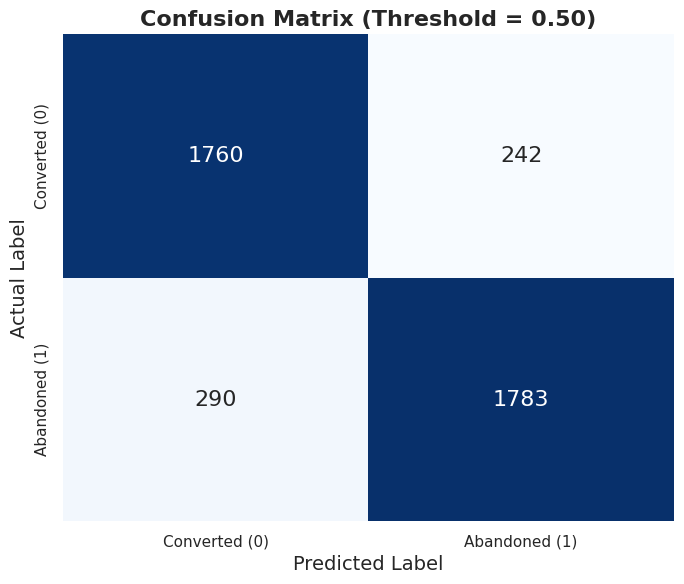

In [13]:
# Confusion Matrix Heatmap
plt.figure(figsize=(7, 6))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            annot_kws={"size": 16},
            xticklabels=['Converted (0)', 'Abandoned (1)'],
            yticklabels=['Converted (0)', 'Abandoned (1)'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('Actual Label', fontsize=14)
plt.title('Confusion Matrix (Threshold = 0.50)', fontsize=16, fontweight='bold')
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=300)
plt.show()

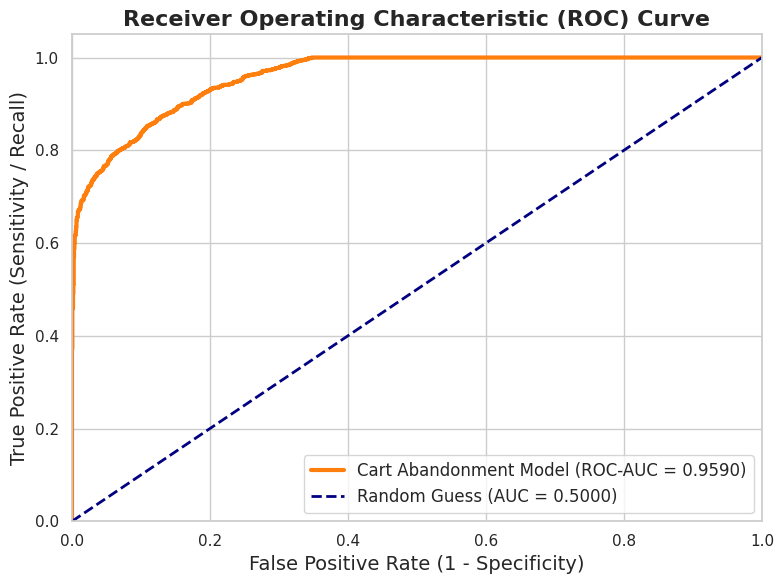

In [14]:
# Compute ROC curve and ROC area
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
roc_auc_val = auc(fpr, tpr)

# Plotting the ROC-AUC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#ff7f0e', lw=3, label=f'Cart Abandonment Model (ROC-AUC = {roc_auc_val:.4f})')

# Plot the diagonal random guessing line (50% baseline)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess (AUC = 0.5000)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=14)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=14)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.savefig('/kaggle/working/roc_auc_curve.png', dpi=300)
plt.show()

In [15]:
# Test

sample_idx = 0  # You can change this to 1, 2, 5, etc.
sample_features = X_test.iloc[[sample_idx]]
actual_label = y_test.iloc[sample_idx]

# Run the prediction using your trained CatBoost model
predicted_proba = abandon_model.predict_proba(sample_features)[:, 1][0]
threshold = 0.50
predicted_label = int(predicted_proba >= threshold)

# Print out the results clearly
print(f"Model Predicted Probability of Abandonment: {predicted_proba:.4f}")
print(f"Model Predicted Action (Threshold = 0.50): {'ABANDONED (Trigger Discount)' if predicted_label == 1 else 'CONVERTED (Do Nothing)'}")
print("-" * 60)
print(f"Actual Ground Truth Label: {'ABANDONED' if actual_label == 1 else 'CONVERTED'}")

# See what the behavioral features of this specific user looked like
print("\n--- User Session Features ---")
for col, val in sample_features.iloc[0].items():
    print(f"  {col}: {val}")

Model Predicted Probability of Abandonment: 0.0001
Model Predicted Action (Threshold = 0.50): CONVERTED (Do Nothing)
------------------------------------------------------------
Actual Ground Truth Label: CONVERTED

--- User Session Features ---
  view_count: 1
  cart_count: 1
  unique_products: 1
  unique_brands: 1
  average_price: 98.37
  max_price: 98.37
  min_price: 98.37
  session_duration: 409.0
  last_event_type: purchase
  last_product_id: 775675
  last_category_id: 2144415923107266682
  last_brand: canon
  last_category_code: computers.peripherals.printer


In [16]:
# Another Test

# Find an index in the test set where the actual label is 1 (Abandoned)
abandoned_indices = y_test[y_test == 1].index

# Pick the first one
test_loc_idx = X_test.index.get_loc(abandoned_indices[0])

sample_features = X_test.iloc[[test_loc_idx]]
actual_label = y_test.iloc[test_loc_idx]

# Run prediction
predicted_proba = abandon_model.predict_proba(sample_features)[:, 1][0]
threshold = 0.50
predicted_label = int(predicted_proba >= threshold)

# Print results
print("=" * 60)
print("KAGGLE LIVE MODEL TEST (ABANDONMENT CASE)")
print("=" * 60)
print(f"Model Predicted Probability of Abandonment: {predicted_proba:.4f}")
print(f"Model Predicted Action (Threshold = 0.50): {'ABANDONED (Trigger Discount!)' if predicted_label == 1 else 'CONVERTED (Do Nothing)'}")
print("-" * 60)
print(f"Actual Ground Truth Label: {'ABANDONED' if actual_label == 1 else 'CONVERTED'}")

# See the features
print("\n--- User Session Features ---")
for col, val in sample_features.iloc[0].items():
    print(f"  {col}: {val}")

KAGGLE LIVE MODEL TEST (ABANDONMENT CASE)
Model Predicted Probability of Abandonment : 0.9161
Model Predicted Action (Threshold = 0.50)  : ABANDONED (Trigger Discount!)
------------------------------------------------------------
Actual Ground Truth Label                  : ABANDONED

--- User Session Features ---
  view_count: 2
  cart_count: 1
  unique_products: 1
  unique_brands: 1
  average_price: 345.44
  max_price: 345.44
  min_price: 345.44
  session_duration: 90.0
  last_event_type: view
  last_product_id: 4155391
  last_category_id: 2144415926806642904
  last_brand: unknown
  last_category_code: computers.components.power_supply


In [17]:
# Save Model
model_path = "/kaggle/working/cart_abandonment_model.cbm"
abandon_model.save_model(model_path)
print(f"[+] Model saved to: {model_path}")

metadata = {
    "model_type": "CatBoostClassifier",
    "target": "abandoned",
    "threshold": 0.50,
    "features": list(X_train.columns),
    "categorical_columns": cat_cols
}

# Save metadata
metadata_path = "/kaggle/working/metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"[+] Metadata saved to: {metadata_path}")

for file in os.listdir("/kaggle/working/"):
    if file.endswith(('.cbm', '.json')):
        size_kb = os.path.getsize(os.path.join("/kaggle/working/", file)) / 1024
        print(f"  • {file} ({size_kb:.2f} KB)")

[+] Model saved to: /kaggle/working/cart_abandonment_model.cbm
[+] Metadata saved to: /kaggle/working/metadata.json
  • cart_abandonment_model.cbm (2730.27 KB)
  • metadata.json (0.59 KB)
